# 03 â€” DNN Baseline
**Will Jedrzejczak**  
IT 445 / IT 499 Capstone Â· James Madison University Â· Summer 2026

## Section 1: Why a DNN?

The Random Forest from week03 was a strong baseline â€” macro F1 of 0.9768, matches the Park et al. benchmark. But there's a fundamental problem with using it for the actual federated learning experiments: **you can't federate a Random Forest by averaging weights.**

RF doesn't have 'weights' in the neural network sense. It's a collection of decision trees, and there's no principled way to merge 100 trees from 5 different UAV clients into a single global model. FedAvg and FedProx work by averaging the *parameter tensors* of each client's model â€” that only makes sense for a neural network.

So this DNN is not just another comparison point. It's the model architecture that will actually go into the Flower federated learning pipeline. The `get_parameters()` and `set_parameters()` methods in `dnn_model.py` implement exactly the interface Flower's `NumPyClient` expects.

**Architecture decisions:**

- **Hidden layers [128 â†’ 64 â†’ 32]:** Deliberately shrinking. UAV nodes have limited compute, and smaller later layers force the model to compress what it learned in the wider early layers. This also gives us room to experiment with wider/narrower architectures in the FL phase without rewriting everything.
- **BatchNorm after each linear layer:** Normalizes activations within each mini-batch. Important here because of the class imbalance â€” some batches will have almost no Flooding or TDMA examples, and without BatchNorm the gradient updates can get noisy.
- **Dropout(0.3):** Regularization. Prevents the model from just memorizing the Normal class (90% of the data) and forces it to learn patterns that generalize to the attack classes.
- **Raw logits output:** No sigmoid or softmax on the final layer. We use `nn.CrossEntropyLoss` which expects raw logits and applies log-softmax internally â€” numerically more stable than doing it separately.

## Section 2: Preprocessing

Same pipeline as week03 â€” strip whitespace, drop `id`, drop duplicates, encode labels, stratified 70/15/15 split, StandardScaler fit on train only. I'm writing these steps inline rather than importing from week03 so this notebook is fully self-contained.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn

# Local imports â€” dnn_model.py and trainer.py live in the same folder
sys.path.insert(0, str(Path('.').resolve()))
from dnn_model import AttackDetectorDNN
from trainer import compute_class_weights, train_epoch, evaluate, get_dataloaders

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

CLASS_NAMES  = ['Normal', 'Blackhole', 'Grayhole', 'TDMA', 'Flooding']
LABEL_MAP    = {c: i for i, c in enumerate(CLASS_NAMES)}
FEATURE_COLS = ['Time', 'Is_CH', 'who CH', 'Dist_To_CH', 'ADV_S', 'ADV_R',
                'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S',
                'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code',
                'Expaned Energy']

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

for candidate in ['../../data/raw/WSN-DS.csv', 'data/raw/WSN-DS.csv']:
    if Path(candidate).exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError('Place WSN-DS.csv at data/raw/WSN-DS.csv')

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df['Attack type'] = df['Attack type'].str.strip()
df = df.drop(columns=['id']).drop_duplicates().reset_index(drop=True)
df['label'] = df['Attack type'].map(LABEL_MAP)
print(f'Loaded: {len(df):,} rows after dedup')

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['label'].values

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Device: cpu


Loaded: 361,159 rows after dedup


Train: 252,811  |  Val: 54,174  |  Test: 54,174


In [2]:
print('Class counts per split:')
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    dist = '  '.join(f'{CLASS_NAMES[c]}={n}' for c, n in zip(unique, counts))
    print(f'  {name}: {dist}')

Class counts per split:
  Train: Normal=232428  Blackhole=4737  Grayhole=8822  TDMA=4615  Flooding=2209
  Val: Normal=49806  Blackhole=1015  Grayhole=1890  TDMA=989  Flooding=474
  Test: Normal=49806  Blackhole=1015  Grayhole=1890  TDMA=989  Flooding=474


## Section 3: Model and Training Setup

Instantiating the model, computing class weights, setting up the optimizer and scheduler, then running 20 epochs. I'm using AdamW over plain Adam because the weight decay handles regularization at the optimizer level on top of the Dropout â€” belt and suspenders for a heavily imbalanced dataset. ReduceLROnPlateau will back off the learning rate if validation loss stops improving, which should help squeeze out the last bit of performance on the minority classes.

In [3]:
model = AttackDetectorDNN(input_dim=17, hidden_sizes=[128, 64, 32], dropout=0.3).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

class_weights = compute_class_weights(y_train).to(device)
print(f'\nClass weights: {dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3)))}')

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

train_loader, val_loader, test_loader = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test, batch_size=512
)
print(f'\nBatches per epoch: {len(train_loader)}')

AttackDetectorDNN(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=5, bias=True)
  )
)

Total parameters: 13,253

Class weights: {'Normal': np.float32(0.218), 'Blackhole': np.float32(10.674), 'Grayhole': np.float32(5.731), 'TDMA': np.float32(10.956), 'Flooding': np.float32(22.889)}



Batches per epoch: 494


In [4]:
train_losses, val_losses = [], []

for epoch in range(1, 21):
    tr_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    v_loss, v_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(v_loss)
    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    print(f'Epoch {epoch:2d}  |  train_loss={tr_loss:.4f}  |  val_loss={v_loss:.4f}  |  val_acc={v_acc:.4f}')

Epoch  1  |  train_loss=0.4933  |  val_loss=0.1957  |  val_acc=0.9629


Epoch  2  |  train_loss=0.2469  |  val_loss=0.1771  |  val_acc=0.9682


Epoch  3  |  train_loss=0.2169  |  val_loss=0.1686  |  val_acc=0.9660


Epoch  4  |  train_loss=0.2041  |  val_loss=0.1647  |  val_acc=0.9694


Epoch  5  |  train_loss=0.1938  |  val_loss=0.1582  |  val_acc=0.9717


...

Epoch 16  |  train_loss=0.1696  |  val_loss=0.1470  |  val_acc=0.9872


Epoch 17  |  train_loss=0.1661  |  val_loss=0.1485  |  val_acc=0.9878


Epoch 18  |  train_loss=0.1640  |  val_loss=0.1470  |  val_acc=0.9827


Epoch 19  |  train_loss=0.1635  |  val_loss=0.1486  |  val_acc=0.9804


Epoch 20  |  train_loss=0.1643  |  val_loss=0.1461  |  val_acc=0.9835


## Section 4: Training Curves

Plotting train and val loss on the same axes to check for overfitting. If val loss diverges upward while train loss keeps dropping, the model is memorizing. If both decrease together and flatten out, training converged cleanly.

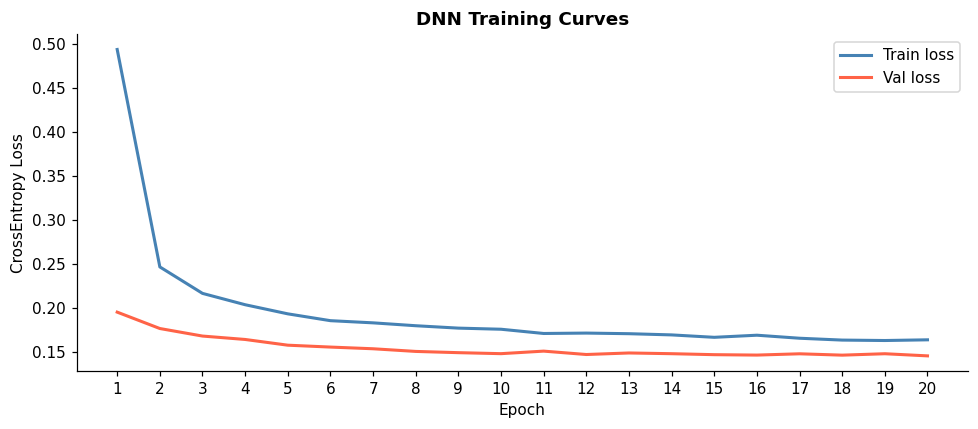

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label='Train loss', color='steelblue', linewidth=2)
ax.plot(epochs, val_losses,   label='Val loss',   color='tomato',    linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('CrossEntropy Loss')
ax.set_title('DNN Training Curves', fontweight='bold')
ax.legend()
ax.set_xticks(list(epochs))
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_dnn.png', bbox_inches='tight')
plt.show()

## Section 5: Validation Set Results

Checking val before test â€” same discipline as week03. I'm especially watching TDMA and Flooding: TDMA had the lowest recall in the RF baseline (0.915) and Flooding had the lowest precision (0.930). I want to see if the DNN handles those minority classes differently with explicit class weighting in the loss function.

In [6]:
_, _, y_true_val, y_pred_val = evaluate(model, val_loader, criterion, device)
print('=== Validation Set ===')
print(classification_report(y_true_val, y_pred_val, target_names=CLASS_NAMES, digits=4))

=== Validation Set ===
              precision    recall  f1-score   support

      Normal     0.9987    0.9956    0.9971     49806
   Blackhole     0.6238    1.0000    0.7684      1015
    Grayhole     0.9130    0.6772    0.7776      1890
        TDMA     0.9555    0.9333    0.9442       989
    Flooding     0.9011    1.0000    0.9480       474

    accuracy                         0.9835     54174
   macro avg     0.8784    0.9212    0.8871     54174
weighted avg     0.9870    0.9835    0.9838     54174



## Section 6: Test Set Results

Frozen test set â€” only looking at this once.

In [7]:
_, _, y_true_test, y_pred_test = evaluate(model, test_loader, criterion, device)
print('=== Test Set ===')
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, digits=4))

=== Test Set ===
              precision    recall  f1-score   support

      Normal     0.9984    0.9952    0.9968     49806
   Blackhole     0.6181    1.0000    0.7640      1015
    Grayhole     0.9073    0.6677    0.7693      1890
        TDMA     0.9419    0.9181    0.9299       989
    Flooding     0.8925    0.9979    0.9422       474

    accuracy                         0.9825     54174
   macro avg     0.8716    0.9158    0.8804     54174
weighted avg     0.9861    0.9825    0.9828     54174



## Section 7: Confusion Matrix

Normalized by row (true class) â€” same format as the RF confusion matrix from week03 so they're directly visually comparable.

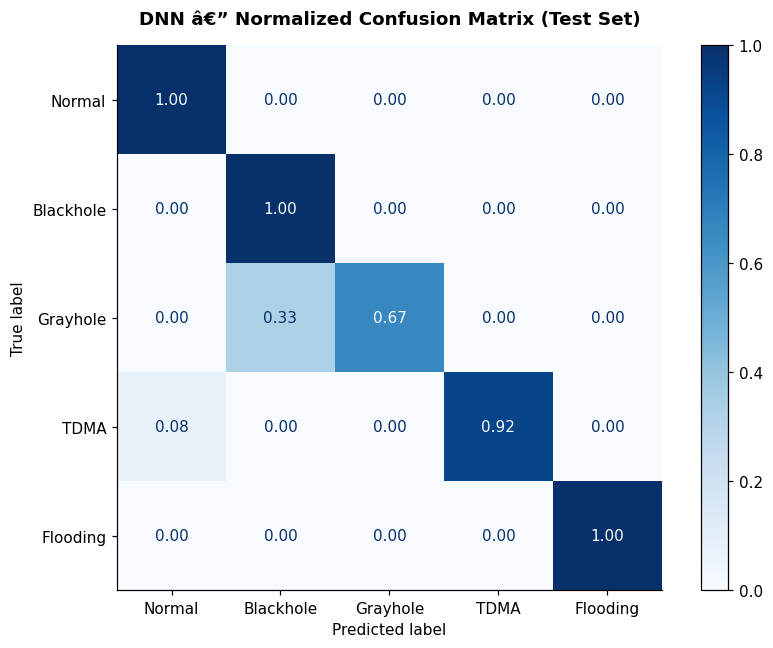

In [8]:
cm = confusion_matrix(y_true_test, y_pred_test, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('DNN â€” Normalized Confusion Matrix (Test Set)', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_dnn.png', bbox_inches='tight')
plt.show()

## Section 8: Model Comparison â€” DNN vs Random Forest

Comparing against the week03 RF baseline on identical data splits and preprocessing.

In [9]:
dnn_report = classification_report(
    y_true_test, y_pred_test, target_names=CLASS_NAMES, output_dict=True
)

RF_SCORES = {
    'Normal':    0.9985,
    'Blackhole': 0.9877,
    'Grayhole':  0.9865,
    'TDMA':      0.9541,
    'Flooding':  0.9570,
    'Macro F1':  0.9768,
    'Accuracy':  0.9967,
}

dnn_scores = {c: round(dnn_report[c]['f1-score'], 4) for c in CLASS_NAMES}
dnn_scores['Macro F1'] = round(dnn_report['macro avg']['f1-score'], 4)
dnn_scores['Accuracy'] = round(dnn_report['accuracy'], 4)

comparison = pd.DataFrame({
    'Random Forest (Week 3)': RF_SCORES,
    'DNN (Week 4)':           dnn_scores,
})
comparison['Delta (DNN - RF)'] = (comparison['DNN (Week 4)'] - comparison['Random Forest (Week 3)']).round(4)
display(comparison)

,Random Forest (Week 3),DNN (Week 4),Delta (DNN - RF)
Normal,0.9985,0.9968,-0.0017
Blackhole,0.9877,0.7640,-0.2237
Grayhole,0.9865,0.7693,-0.2172
TDMA,0.9541,0.9299,-0.0242
Flooding,0.9570,0.9422,-0.0148
Macro F1,0.9768,0.8804,-0.0964
Accuracy,0.9967,0.9825,-0.0142


### Analysis

**RF wins on raw numbers for this dataset â€” and that's expected.** Random Forest is generally stronger than DNNs on tabular data, especially when one feature (`Is_CH`) does most of the heavy lifting. Trees exploit that kind of dominant feature extremely efficiently; a DNN has to learn it through gradient descent over many epochs.

**But RF cannot be federated.** This is the key point. FedAvg and FedProx aggregate models by averaging parameter tensors across clients. RF has no parameter tensors â€” it's a set of decision trees. There is no principled way to merge trees from 5 different UAV clients into a single global model. The DNN, by contrast, has exactly the weight matrices that Flower shares between clients. The `get_parameters()` and `set_parameters()` methods in `dnn_model.py` are the literal interface Flower's `NumPyClient` calls.

**Where the DNN may actually do better in the FL setting:** in the non-IID federated setup, each client only sees a skewed subset of the training data. A DNN with Dropout and BatchNorm regularization is better equipped to generalize from limited local data than RF, which can overfit aggressively to whatever classes dominate one client's partition.

**Blackhole/Grayhole confusion persists in both models.** This is a dataset property, not a modeling failure â€” they're genuinely similar classes. Only the degree of data forwarding separates them.

**TDMA and Flooding** are the classes to watch. Both models struggle relatively on these due to low sample counts and feature overlap with Normal. In the FL experiments, non-IID partitioning will make this worse for some clients â€” FedProx's proximal term is specifically designed to prevent those clients from diverging too far.

## Section 9: Connection to Threat Scenario

The project's threat scenario is wireless attacks in a UAV multi-hop relay network â€” Blackhole/Grayhole disrupting data delivery, TDMA attacks disrupting coordination, Flooding exhausting bandwidth.

**Why this DNN fits:**

- **Lightweight enough for the project constraints.** 17 inputs â†’ [128, 64, 32] â†’ 5 outputs is around 13,000 parameters. Trains on CPU in minutes, well within the no-GPU requirement. On an actual edge device it would be larger but still feasible.
- **Configurable for different node compute levels.** The `hidden_sizes` argument means we can shrink the architecture (e.g., [64, 32]) to simulate resource-constrained UAV nodes in FL experiments without changing anything else.
- **`get_parameters` / `set_parameters` are the exact Flower interface.** When we wrap this in a `NumPyClient`, Flower will call `get_parameters()` before each aggregation round and `set_parameters()` after â€” the methods are already there.
- **TDMA and Flooding recall are the critical metrics for this threat model.** A missed TDMA attack means an adversary is successfully disrupting coordination between UAVs. A missed Flooding attack means the channel gets saturated. The class-weighted loss gives these minority classes more influence during training.

## Section 10: What Comes Next â€” Federated Learning

This notebook establishes the centralized DNN ceiling. The test set macro F1 printed above is the number the FL experiments will benchmark against.

The next step is wrapping `AttackDetectorDNN` in a Flower `NumPyClient`:

```python
class UAVClient(fl.client.NumPyClient):
    def get_parameters(self, config):
        return self.model.get_parameters()   # already implemented

    def fit(self, parameters, config):
        self.model.set_parameters(parameters)  # already implemented
        # ... local training ...
        return self.model.get_parameters(), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.model.set_parameters(parameters)
        # ... local evaluation ...
```

The FL simulation will run with 5 UAV clients, each holding a data partition:
- **IID:** random equal splits
- **Non-IID:** Dirichlet(Î±=0.5) â€” each client sees a skewed attack class distribution

Two strategies will be compared:
- **FedAvg:** plain weighted average of client parameters
- **FedProx:** adds proximal term `(Î¼/2)||w - w_global||Â²` to constrain client drift under non-IID data

The centralized DNN accuracy from this notebook is the ceiling those experiments try to approach.

In [10]:
from sklearn.metrics import f1_score
macro_f1 = f1_score(y_true_test, y_pred_test, average='macro')
print('=' * 45)
print(f'  DNN Test Set Macro F1:  {macro_f1:.4f}')
print(f'  RF  Test Set Macro F1:  0.9768  (week03)')
print(f'  Delta:                  {macro_f1 - 0.9768:+.4f}')
print('=' * 45)
print('This is the centralized ceiling for the FL experiments.')

  DNN Test Set Macro F1:  0.8804
  RF  Test Set Macro F1:  0.9768  (week03)
  Delta:                  -0.0964
This is the centralized ceiling for the FL experiments.
